In [1]:
import sqlite3
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

clv_model = joblib.load("../models_clv.pkl")
churn_model = joblib.load("../models_churn.pkl")

print(df.shape)
print(df["customer_state"].value_counts().head(10))

(93397, 20)
customer_state
SP    39155
RJ    11917
MG    11002
RS     5168
PR     4769
SC     3449
BA     3158
DF     2019
ES     1928
GO     1895
Name: count, dtype: int64


In [2]:
clv_features = ["recency_days", "frequency", "repeat_order_count",
                 "avg_days_between_orders", "avg_review_score", "review_count",
                 "avg_delivery_days", "avg_delay_days"]
churn_features = ["frequency", "repeat_order_count", "avg_days_between_orders",
                   "avg_review_score", "review_count", "avg_delivery_days",
                   "avg_delay_days", "treatment_voucher"]

audit_df = df.dropna(subset=clv_features + churn_features + ["customer_state"]).copy()

audit_df["predicted_clv"] = clv_model.predict(audit_df[clv_features])
audit_df["predicted_churn_prob"] = churn_model.predict_proba(audit_df[churn_features])[:, 1]

print(audit_df.shape)

(92786, 22)


In [3]:
state_counts = audit_df["customer_state"].value_counts()

# Keep states with reasonable sample size; group the rest as "Other (low volume)"
min_sample = 100
audit_df["state_group"] = audit_df["customer_state"].apply(
    lambda s: s if state_counts[s] >= min_sample else "Other (low volume)"
)

print(audit_df["state_group"].value_counts())

state_group
SP                    38932
RJ                    11790
MG                    10937
RS                     5150
PR                     4748
SC                     3423
BA                     3133
DF                     2009
ES                     1905
GO                     1884
PE                     1538
CE                     1252
PA                      911
MT                      850
MA                      695
MS                      679
PB                      499
RN                      461
PI                      460
AL                      385
SE                      328
TO                      266
RO                      231
Other (low volume)      181
AM                      139
Name: count, dtype: int64


In [4]:
regional_summary = audit_df.groupby("state_group").agg(
    n_customers=("customer_unique_id", "count"),
    avg_predicted_clv=("predicted_clv", "mean"),
    avg_predicted_churn_prob=("predicted_churn_prob", "mean"),
    avg_actual_monetary=("monetary", "mean"),
    avg_actual_churn_rate=("churned", "mean")
).sort_values("n_customers", ascending=False)

print(regional_summary)

                    n_customers  avg_predicted_clv  avg_predicted_churn_prob  \
state_group                                                                    
SP                        38932         151.787938                  0.469957   
RJ                        11790         174.193415                  0.588856   
MG                        10937         166.549659                  0.571714   
RS                         5150         176.454176                  0.612841   
PR                         4748         166.598247                  0.568752   
SC                         3423         171.349077                  0.627735   
BA                         3133         182.818388                  0.683823   
DF                         2009         168.101102                  0.593312   
ES                         1905         172.599649                  0.643793   
GO                         1884         175.056752                  0.640816   
PE                         1538         

                    n_customers    clv_gap  churn_pred_gap
state_group                                               
PB                          499 -83.269129       -0.117277
AL                          385 -50.853543       -0.109033
TO                          266 -46.300120       -0.116331
PI                          460 -45.314506       -0.164749
RO                          231 -41.283427       -0.257332
Other (low volume)          181 -33.412785       -0.238717
RN                          461 -33.342517       -0.171495
PA                          911 -29.708712       -0.159534
MA                          695 -27.909771       -0.132574
CE                         1252 -26.820696       -0.142548
MT                          850 -26.192394       -0.166592
SE                          328 -25.575707       -0.090559
MS                          679 -24.034599       -0.154092
PE                         1538 -16.099292       -0.147279
BA                         3133  -4.760466       -0.1259

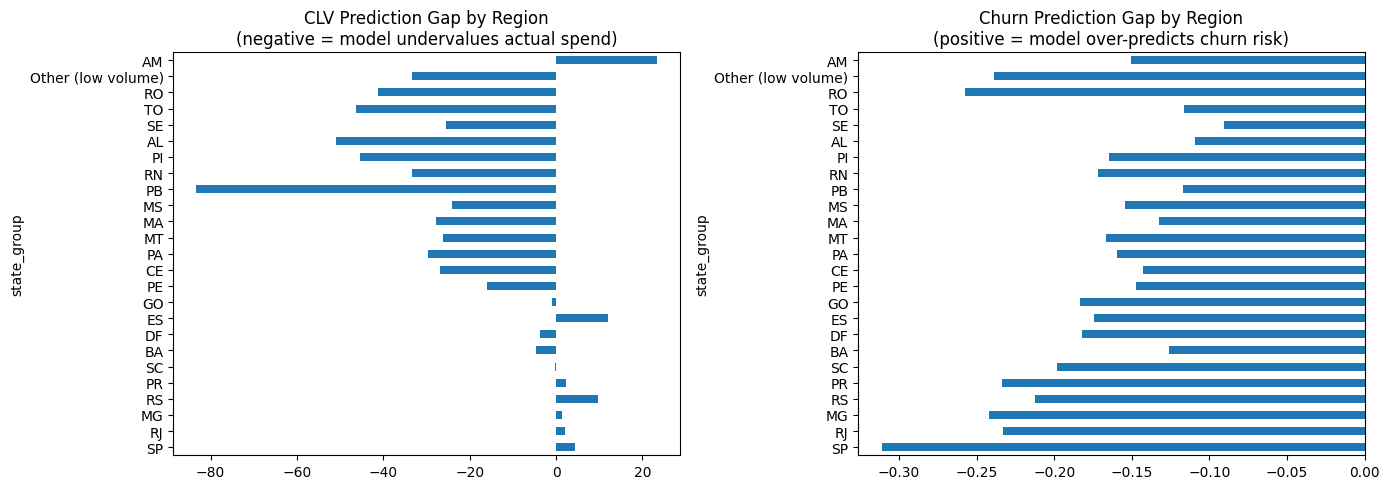

In [5]:
regional_summary["clv_gap"] = regional_summary["avg_predicted_clv"] - regional_summary["avg_actual_monetary"]
regional_summary["churn_pred_gap"] = regional_summary["avg_predicted_churn_prob"] - regional_summary["avg_actual_churn_rate"]

print(regional_summary[["n_customers", "clv_gap", "churn_pred_gap"]].sort_values("clv_gap"))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
regional_summary["clv_gap"].plot(kind="barh", ax=ax[0], title="CLV Prediction Gap by Region\n(negative = model undervalues actual spend)")
regional_summary["churn_pred_gap"].plot(kind="barh", ax=ax[1], title="Churn Prediction Gap by Region\n(positive = model over-predicts churn risk)")
plt.tight_layout()
plt.savefig("../docs/fairness_regional_gaps.png", dpi=150, bbox_inches="tight")
plt.show()